# 90 - Knockout scores: quarterfinals onward, 2006-2026

How do late-knockout matches actually behave? This notebook takes every match from the quarterfinals on -- quarterfinals, semifinals, the third-place match and the final -- across the last five *completed* World Cups (2006-2022, eight such matches each) plus whatever the in-progress 2026 edition has already played from the quarterfinals onward, and looks at the distribution of **full-time (90-minute) scores** and of the scores **after extra time** for ties that were level.

These matches are the empirical base rates that the simulator's knockout machinery (Poisson scorelines, then extra time as a scaled-down match, then a penalty lottery) is meant to reproduce, so at the end we check its extra-time scaling assumption against the data. Unplayed 2026 fixtures are skipped, so the sample grows on its own as the tournament finishes and the data is refreshed.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from wcpredictor.config import default_config
from wcpredictor.simulation.match import EXTRA_TIME_FRACTION

config = default_config()
plt.rcParams['figure.figsize'] = (9, 4.5)

SOURCE_DIR = config.wc2026_source_path.parent
YEARS = [2006, 2010, 2014, 2018, 2022, 2026]
COMPLETED = [y for y in YEARS if y != 2026]
# openfootball's round labels vary by year; canonicalise QF onward.
ROUND_LABELS = {
    'Quarterfinals': 'QF', 'Quarter-finals': 'QF', 'Quarter-final': 'QF',
    'Semifinals': 'SF', 'Semi-finals': 'SF', 'Semi-final': 'SF',
    'Third-place play-off': '3rd place',
    'Match for third place': '3rd place',
    'Final': 'Final',
}
STAGE_ORDER = ['QF', 'SF', '3rd place', 'Final']

## The matches

Read straight from the vendored `data/source/*.worldcup.json` files rather than `matches.csv`, because only the source JSON keeps the full-time and after-extra-time scores apart: `score.ft` is the 90-minute score and `score.et`, when present, the cumulative score after 120 minutes (`score.p` records a shootout). The *settled* score is the one on the scoreboard when the tie was decided: after extra time where it was played, after 90 minutes otherwise. Fixtures with no full-time score yet (the still-to-be-played 2026 rounds) are skipped.

In [2]:
rows = []
for year in YEARS:
    doc = json.loads((SOURCE_DIR / f'{year}.worldcup.json')
                     .read_text(encoding='utf-8'))
    matches = list(doc.get('matches', []))
    for rnd in doc.get('rounds', []):
        matches.extend(rnd.get('matches', []))
    for m in matches:
        stage = ROUND_LABELS.get((m.get('round') or '').strip())
        if stage is None:
            continue
        s = m.get('score') or {}
        ft, et, pens = s.get('ft'), s.get('et'), s.get('p')
        if ft is None:
            continue  # not played yet (2026 rounds still to come)
        fin = et or ft  # the settled score (see above)
        rows.append({'year': year, 'stage': stage,
                     'team1': m['team1'], 'team2': m['team2'],
                     'ft1': ft[0], 'ft2': ft[1],
                     'fin1': fin[0], 'fin2': fin[1],
                     'extra_time': et is not None,
                     'penalties': pens is not None})
df = pd.DataFrame(rows)
df['stage'] = pd.Categorical(df['stage'], STAGE_ORDER, ordered=True)
per_year = df.groupby('year').size()
assert (per_year.loc[COMPLETED] == 8).all(), \
    'expected 8 matches per completed WC from the QF on'
print(f'{len(df)} matches across {len(YEARS)} World Cups '
      f'({per_year.get(2026, 0)} of them from the in-progress 2026):')
print(per_year.to_string())
df.head()

44 matches across 6 World Cups (4 of them from the in-progress 2026):
year
2006    8
2010    8
2014    8
2018    8
2022    8
2026    4


,year,stage,team1,team2,ft1,ft2,fin1,fin2,extra_time,penalties
0,2006,QF,Germany,Argentina,1,1,1,1,True,True
1,2006,QF,Italy,Ukraine,3,0,3,0,False,False
2,2006,QF,England,Portugal,0,0,0,0,True,True
3,2006,QF,Brazil,France,0,1,0,1,False,False
4,2006,SF,Germany,Italy,0,0,0,2,True,False


## How often does 90 minutes fail to settle it?

In a knockout, a full-time draw *is* extra time, so the FT draw rate doubles as the extra-time rate.

In [3]:
summary = (df.groupby('stage', observed=True)
             .agg(matches=('year', 'size'),
                  extra_time=('extra_time', 'sum'),
                  penalties=('penalties', 'sum')))
summary['ft_draw_rate'] = summary['extra_time'] / summary['matches']
print(f"Overall: {df['extra_time'].mean():.0%} level after 90 minutes "
      f"({df['extra_time'].sum()} of {len(df)}); "
      f"{df['penalties'].sum()} decided on penalties.")
summary

Overall: 36% level after 90 minutes (16 of 44); 10 decided on penalties.


,matches,extra_time,penalties,ft_draw_rate
stage,,,,
QF,24,9,7,0.375
SF,10,3,1,0.300
3rd place,5,0,0,0.000
Final,5,4,2,0.800


## Full-time scorelines

Scorelines as winner-loser (venue is irrelevant at a neutral tournament), draws in grey. Late knockouts are tight, low-scoring affairs -- compare the group-stage goal distributions in notebook 01.

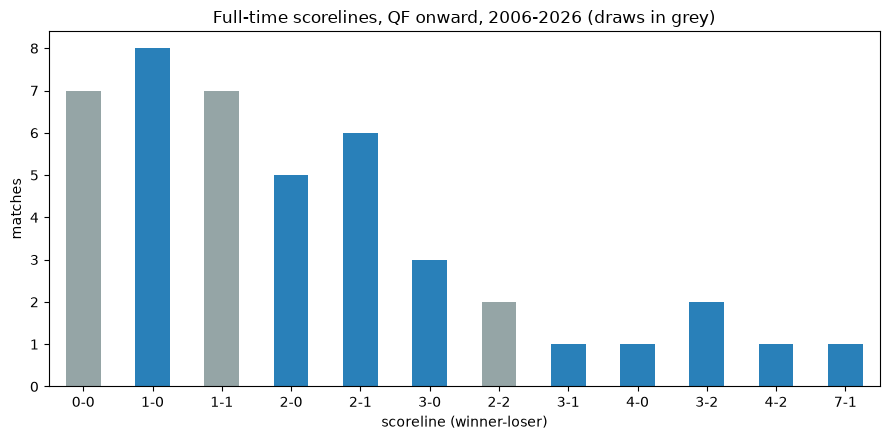

mean FT goals/match: 2.25 (vs 44 matches)


In [4]:
def scoreline(a, b):
    return f'{max(a, b)}-{min(a, b)}'

def by_goals(index):
    return sorted(index, key=lambda s: (sum(map(int, s.split('-'))), s))

ft_scores = df.apply(lambda r: scoreline(r['ft1'], r['ft2']), axis=1)
counts = ft_scores.value_counts().loc[by_goals(ft_scores.unique())]
is_draw = [s.split('-')[0] == s.split('-')[1] for s in counts.index]
colors = ['#95a5a6' if d else '#2980b9' for d in is_draw]
ax = counts.plot.bar(color=colors, rot=0)
ax.set_title(f'Full-time scorelines, QF onward, '
             f'{YEARS[0]}-{YEARS[-1]} (draws in grey)')
ax.set_xlabel('scoreline (winner-loser)'); ax.set_ylabel('matches')
plt.tight_layout(); plt.show()
print(f"mean FT goals/match: {(df['ft1'] + df['ft2']).mean():.2f} "
      f"(vs {counts.sum()} matches)")

## ...and after extra time: the settled scorelines

The same distribution once the level ties have played their extra 30 minutes. Draw cells shrink but do not vanish -- a scoreline still level after 120 minutes means the tie went to penalties.

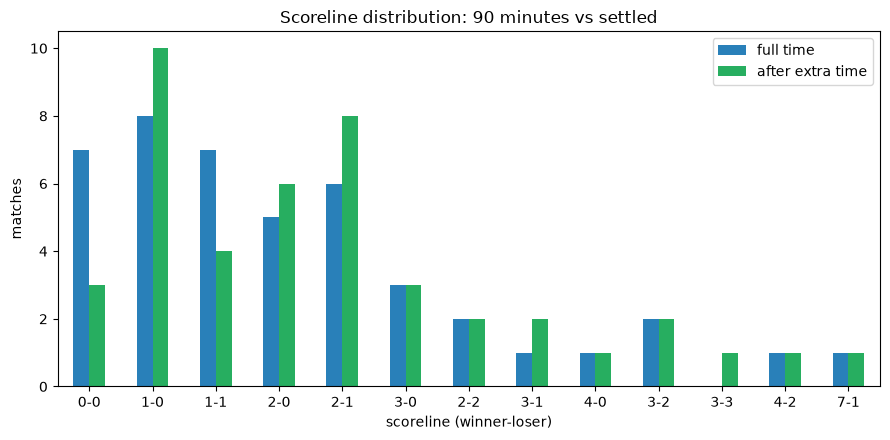

Settled-score draws (decided on penalties):
1-1    4
0-0    3
2-2    2
3-3    1


In [5]:
fin_scores = df.apply(lambda r: scoreline(r['fin1'], r['fin2']), axis=1)
comp = (pd.DataFrame({'full time': ft_scores.value_counts(),
                      'after extra time': fin_scores.value_counts()})
        .fillna(0).astype(int))
comp = comp.loc[by_goals(comp.index)]
ax = comp.plot.bar(color=['#2980b9', '#27ae60'], rot=0)
ax.set_title('Scoreline distribution: 90 minutes vs settled')
ax.set_xlabel('scoreline (winner-loser)'); ax.set_ylabel('matches')
plt.tight_layout(); plt.show()
still_level = fin_scores[df['penalties']].value_counts()
print('Settled-score draws (decided on penalties):')
print(still_level.to_string())

### Total goals, before and after extra time

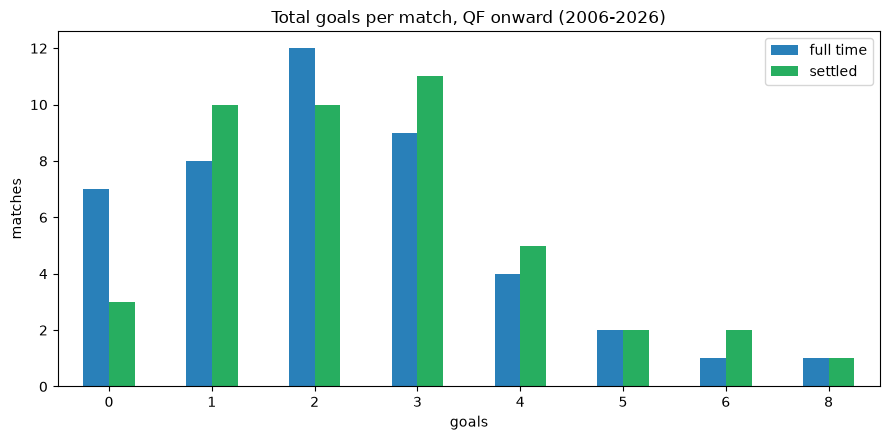

In [6]:
tg = (pd.DataFrame({'full time': (df['ft1'] + df['ft2']).value_counts(),
                    'settled': (df['fin1'] + df['fin2']).value_counts()})
      .fillna(0).astype(int).sort_index())
ax = tg.plot.bar(color=['#2980b9', '#27ae60'], rot=0)
ax.set_title(f'Total goals per match, QF onward '
             f'({YEARS[0]}-{YEARS[-1]})')
ax.set_xlabel('goals'); ax.set_ylabel('matches')
plt.tight_layout(); plt.show()

## Does extra time score like a third of a match?

The simulator plays extra time as the same Poisson attack/defense matchup scaled by `EXTRA_TIME_FRACTION` (30/90 of the expected goals -- see `wcpredictor.simulation.match`). Check that assumption against these tournaments: goals actually scored in extra-time periods vs what a third of the observed 90-minute scoring rate would predict.

In [7]:
et_games = df[df['extra_time']]
et_goals = ((et_games['fin1'] - et_games['ft1'])
            + (et_games['fin2'] - et_games['ft2']))
ft_rate = (df['ft1'] + df['ft2']).mean()
print(f'{len(et_games)} matches went to extra time; '
      f'{int(et_goals.sum())} goals were scored in those periods.')
print(f'observed goals per ET period:            {et_goals.mean():.2f}')
print(f'FT rate x EXTRA_TIME_FRACTION ({EXTRA_TIME_FRACTION:.2f}): '
      f'{ft_rate * EXTRA_TIME_FRACTION:.2f}')
se = et_goals.std(ddof=1) / np.sqrt(len(et_goals))
print(f'(+/-1 s.e. on the observed rate: {se:.2f} -- '
      f'{len(et_goals)} matches is a small sample)')
print(f'ET matches settled without penalties: '
      f'{1 - et_games["penalties"].mean():.0%}')

16 matches went to extra time; 14 goals were scored in those periods.
observed goals per ET period:            0.88
FT rate x EXTRA_TIME_FRACTION (0.33): 0.75
(+/-1 s.e. on the observed rate: 0.22 -- 16 matches is a small sample)
ET matches settled without penalties: 38%


### Reading the result

Two caveats before over-interpreting any gap between the two rates. The sample is tiny (a handful of extra-time matches per tournament), so the standard error above can span the whole difference. And matches that reach extra time are not a random sample: they are ties between well-matched sides, played on tired legs -- caution and fatigue push scoring down, while the urgency of avoiding a shootout pushes it up, so the selection effects cut both ways. If the observed rate lands near the one-third scaling, that is direct empirical support for the simulator's independent-Poisson extra time (deliberately without the Dixon-Coles draw correction, which models 90-minute dependence); a persistent gap in either direction would justify fitting a separate extra-time intercept from exactly this data.